# Ensemble Methods

## What are Ensemble Methods?
Ensemble methods combine multiple models to produce a better predictor. The intuition: **wisdom of the crowd** many weak learners combined > one strong learner.

Three main paradigms:
1. **Bagging** parallel, reduce variance
2. **Boosting** sequential, reduce bias
3. **Stacking** meta-learning

---

## 1. Bagging (Bootstrap Aggregating)

Train $B$ models on bootstrap samples, then aggregate:

$$\hat{f}_{bag}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat{f}^{*b}(x)$$

Why it works: Each bootstrap sample has ~63.2% of original data. Averaging reduces variance by factor of $B$ (if models uncorrelated):

$$\text{Var}\left(\frac{1}{B}\sum X_i\right) = \frac{\sigma^2}{B}$$

---

## 2. Random Forest

Bagging + **feature subsampling** at each split:
- At each node, sample $m$ features (typically $m = \sqrt{p}$ for classification, $m = p/3$ for regression)
- This decorrelates the trees → further variance reduction

**OOB (Out-of-Bag) Error**: Each tree is tested on ~36.8% of data not in its bootstrap sample. Free validation set!

---

## 3. Gradient Boosting

Build trees **sequentially**, each correcting the previous:

$$F_m(x) = F_{m-1}(x) + \gamma_m h_m(x)$$

Where $h_m$ is fit to the **negative gradient** (pseudo-residuals):

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

For MSE loss: $r_{im} = y_i - F_{m-1}(x_i)$ (actual residuals)

Learning rate shrinkage: $F_m(x) = F_{m-1}(x) + \nu \gamma_m h_m(x)$, where $\nu \in (0,1]$

---

## 4. AdaBoost

Weight misclassified examples more:

Stage $m$ error: $\epsilon_m = \sum_{i: y_i \neq h_m(x_i)} w_i$

Model weight: $\alpha_m = \frac{1}{2}\ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)$

Weight update:
$$w_i^{(m+1)} = w_i^{(m)} \cdot \exp\left(-\alpha_m y_i h_m(x_i)\right)$$

Final prediction: $H(x) = \text{sign}\left(\sum_{m=1}^M \alpha_m h_m(x)\right)$

---

## 5. XGBoost

Regularized objective:
$$\mathcal{L} = \sum_{i} l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

Where: $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|w\|^2$ ($T$ = leaves, $w$ = leaf weights)

Second-order Taylor expansion:
$$\mathcal{L}^{(t)} \approx \sum_i \left[g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i)\right] + \Omega(f_t)$$

Where $g_i = \partial_{\hat{y}}l$, $h_i = \partial^2_{\hat{y}}l$

Optimal leaf weight: $w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$

---

## 6. LightGBM

Key innovations:
- **GOSS** (Gradient-based One-Side Sampling): Keep large-gradient samples + random sample of small-gradient
- **EFB** (Exclusive Feature Bundling): Bundle mutually exclusive features
- **Leaf-wise** growth (vs. level-wise in XGBoost) → faster, but more prone to overfitting

---

## 7. Stacking

Train Level-0 models → use their predictions as features for Level-1 meta-learner:

$$\hat{y} = g(\hat{f}_1(x), \hat{f}_2(x), \ldots, \hat{f}_k(x))$$

Must use **cross-validation** to generate OOF (out-of-fold) predictions to avoid data leakage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Bagging from Scratch

In [2]:
class BaggingScratch:
    def __init__(self, n_estimators=50, max_depth=5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        m = len(y)
        for _ in range(self.n_estimators):
            idx = np.random.choice(m, m, replace=True)  # bootstrap
            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        votes = np.array([t.predict(X) for t in self.trees])  # (n_trees, n_samples)
        return np.array([np.bincount(votes[:, i]).argmax() for i in range(X.shape[0])])


bag = BaggingScratch(n_estimators=100, max_depth=5)
bag.fit(X_train, y_train)
print(f'Bagging Scratch Accuracy: {accuracy_score(y_test, bag.predict(X_test)):.4f}')

Bagging Scratch Accuracy: 0.9561


## All Ensembles Comparison

In [3]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Single Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    cv = cross_val_score(model, X, y, cv=skf, scoring='accuracy').mean()
    results[name] = (acc, cv)
    print(f'{name:25s} | Test Acc: {acc:.4f} | CV Acc: {cv:.4f}')

Single Tree               | Test Acc: 0.9474 | CV Acc: 0.9280


Bagging                   | Test Acc: 0.9561 | CV Acc: 0.9543


Random Forest             | Test Acc: 0.9649 | CV Acc: 0.9561


AdaBoost                  | Test Acc: 0.9737 | CV Acc: 0.9666


Gradient Boosting         | Test Acc: 0.9561 | CV Acc: 0.9491


## XGBoost & LightGBM

In [4]:
try:
    import xgboost as xgb
    import lightgbm as lgb

    xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                   use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    print(f'XGBoost Accuracy: {accuracy_score(y_test, xgb_model.predict(X_test)):.4f}')

    lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
    lgb_model.fit(X_train, y_train)
    print(f'LightGBM Accuracy: {accuracy_score(y_test, lgb_model.predict(X_test)):.4f}')

except ImportError:
    print('Install: pip install xgboost lightgbm')

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:31:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9561
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Feature Importance: Random Forest vs XGBoost

Tree-based models expose `.feature_importances_` but the metric differs:

- **Random Forest (impurity-based / Mean Decrease Impurity):** Measures the total reduction in
  Gini impurity (or entropy) across all splits that use a feature, averaged over all trees.
  Fast to compute but can be biased toward high-cardinality features.

- **XGBoost (gain-based):** Measures the average gain in the objective function brought by a
  feature across all splits where it is used. Gain is computed from the second-order Taylor
  approximation used during tree building, making it a more faithful measure of each feature's
  contribution to reducing loss.

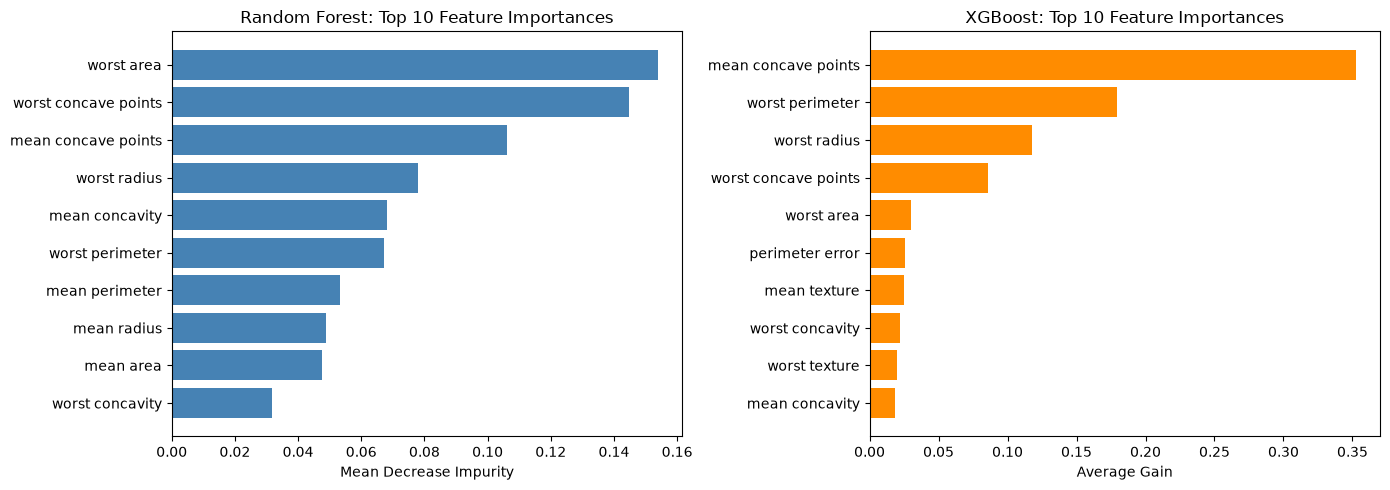

In [5]:
try:
    import xgboost as xgb

    # Train models to extract importances
    rf_fi = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_fi.fit(X_train, y_train)

    xgb_fi = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                eval_metric='logloss', random_state=42)
    xgb_fi.fit(X_train, y_train, verbose=False)

    n_top = 10
    rf_imp = rf_fi.feature_importances_
    xgb_imp = xgb_fi.feature_importances_

    rf_idx = np.argsort(rf_imp)[::-1][:n_top]
    xgb_idx = np.argsort(xgb_imp)[::-1][:n_top]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.barh(range(n_top), rf_imp[rf_idx][::-1], color='steelblue')
    ax1.set_yticks(range(n_top))
    ax1.set_yticklabels([feature_names[i] for i in rf_idx[::-1]])
    ax1.set_xlabel('Mean Decrease Impurity')
    ax1.set_title('Random Forest: Top 10 Feature Importances')

    ax2.barh(range(n_top), xgb_imp[xgb_idx][::-1], color='darkorange')
    ax2.set_yticks(range(n_top))
    ax2.set_yticklabels([feature_names[i] for i in xgb_idx[::-1]])
    ax2.set_xlabel('Average Gain')
    ax2.set_title('XGBoost: Top 10 Feature Importances')

    plt.tight_layout()
    plt.show()

except ImportError:
    print('Install xgboost: pip install xgboost')

## XGBoost Early Stopping

Early stopping monitors a validation metric during training and halts when it stops improving
for a given number of rounds (`early_stopping_rounds`). This prevents overfitting without
manually tuning `n_estimators` and speeds up training on large datasets.

The model checkpoints the best iteration internally and uses it for prediction automatically.

Best iteration: 88


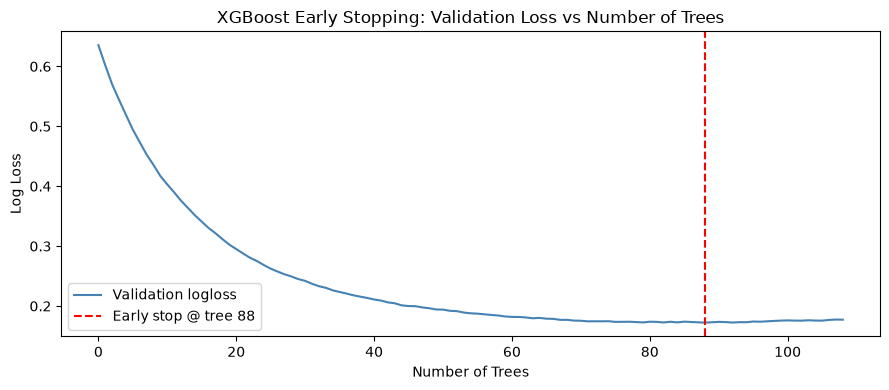

In [6]:
try:
    from xgboost import XGBClassifier

    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # In XGBoost >= 2.0, early_stopping_rounds goes in the constructor, not fit()
    xgb_es = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42,
                            eval_metric='logloss', early_stopping_rounds=20)
    xgb_es.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    print(f'Best iteration: {xgb_es.best_iteration}')

    # Plot validation loss vs number of trees
    evals_result = xgb_es.evals_result()
    val_loss = evals_result['validation_0']['logloss']
    best_iter = xgb_es.best_iteration

    plt.figure(figsize=(9, 4))
    plt.plot(val_loss, label='Validation logloss', color='steelblue')
    plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Early stop @ tree {best_iter}')
    plt.xlabel('Number of Trees')
    plt.ylabel('Log Loss')
    plt.title('XGBoost Early Stopping: Validation Loss vs Number of Trees')
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError:
    print('Install xgboost: pip install xgboost')

## Stacking

In [7]:
from sklearn.svm import SVC

estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5, passthrough=False
)
stacking.fit(X_train_s, y_train)
print(f'Stacking Accuracy: {stacking.score(X_test_s, y_test):.4f}')

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Stacking Accuracy: 0.9649


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)`

## Voting Classifier

Voting combines predictions from multiple heterogeneous classifiers:

- **Hard voting:** Each model casts a class vote; the majority class wins. Works well when
  models are diverse and comparably accurate.

- **Soft voting:** Models output class probabilities; probabilities are averaged and the
  highest-probability class is chosen. Soft voting generally outperforms hard voting when the
  models are well-calibrated (their predicted probabilities reflect true likelihoods), because
  it exploits confidence information rather than just binary votes.

In [8]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

skf_vote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

estimators_vote = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier(max_depth=5)),
    ('svc', SVC(probability=True))
]

hard_voting = VotingClassifier(estimators=estimators_vote, voting='hard')
soft_voting = VotingClassifier(estimators=estimators_vote, voting='soft')

# Best single model from the comparison above (AdaBoost)
best_single = AdaBoostClassifier(n_estimators=100, random_state=42)

hard_cv = cross_val_score(hard_voting, X_train_s, y_train, cv=skf_vote, scoring='accuracy').mean()
soft_cv = cross_val_score(soft_voting, X_train_s, y_train, cv=skf_vote, scoring='accuracy').mean()
best_cv = cross_val_score(best_single, X_train, y_train, cv=skf_vote, scoring='accuracy').mean()

print(f'Hard Voting CV Accuracy : {hard_cv:.4f}')
print(f'Soft Voting CV Accuracy : {soft_cv:.4f}')
print(f'Best Single Model CV    : {best_cv:.4f} (AdaBoost)')

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Hard Voting CV Accuracy : 0.9692
Soft Voting CV Accuracy : 0.9714
Best Single Model CV    : 0.9670 (AdaBoost)


## CatBoost vs XGBoost vs LightGBM

All three are gradient boosted tree libraries but differ in key design choices:

| Feature | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| Tree growth | Level-wise | Leaf-wise | Symmetric (oblivious) |
| Categorical features | Manual encoding required | Built-in (integer encoding) | Native ordered target encoding |
| Gradient computation | Standard | GOSS (keep large-gradient + random small) | Ordered boosting (prevents target leakage) |
| GPU support | Yes | Yes | Yes |
| Overfitting on small data | Moderate | Higher risk (leaf-wise) | Lower risk (symmetric trees) |

**When to choose:**
- **XGBoost:** Well-understood, great ecosystem, solid baseline for most tabular problems.
- **LightGBM:** Fastest training on large datasets; preferred when you have millions of rows.
- **CatBoost:** Best when you have many categorical features and want to skip manual encoding;
  also tends to work well out of the box with minimal hyperparameter tuning.

In [9]:
try:
    from catboost import CatBoostClassifier
    cat = CatBoostClassifier(iterations=200, verbose=0, random_state=42)
    cat.fit(X_train, y_train)
    score = cat.score(X_test, y_test)
    print(f'CatBoost test accuracy: {score:.4f}')
except ImportError:
    print('CatBoost not installed. Run: pip install catboost')

CatBoost not installed. Run: pip install catboost


## Additional Learning Resources

### Papers
- 📄 [Random Forests Breiman (2001)](https://link.springer.com/article/10.1023/A:1010933404324)
- 📄 [XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754) Chen & Guestrin
- 📄 [LightGBM: A Highly Efficient Gradient Boosting Decision Tree](https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html)
- 📄 [Greedy Function Approximation: A Gradient Boosting Machine (Friedman 2001)](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full)
- 📄 [AdaBoost Freund & Schapire (1997)](https://www.sciencedirect.com/science/article/pii/S002200009791504X)

### Books
- 📖 [ESL Chapter 15-16](https://web.stanford.edu/~hastie/ElemStatLearn/) Random Forests, Boosting

### Videos
- 🎥 [StatQuest: Random Forests](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ)
- 🎥 [StatQuest: Gradient Boost](https://www.youtube.com/watch?v=3CC4N4z3GJc)
- 🎥 [StatQuest: AdaBoost](https://www.youtube.com/watch?v=LsK-xG1cLYA)
- 🎥 [XGBoost Paper Explained](https://www.youtube.com/watch?v=OtD8wVaFm6E)

### Documentation
- 📚 [XGBoost Docs](https://xgboost.readthedocs.io/)
- 📚 [LightGBM Docs](https://lightgbm.readthedocs.io/)
- 📚 [CatBoost Docs](https://catboost.ai/docs/)
- 📚 [Scikit-Learn Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html)